In [32]:
import pandas as pd
import json
import numpy as np
import math
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
import torch.nn.functional as F
import matplotlib.pyplot as plt
import selfies as sf
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs, rdmolops, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm import tqdm
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score
from scipy.signal import find_peaks

In [ ]:
# load parquet files
data_dir = Path('/home/andrze06/projects/Spectras-latent-space/data/multimodal_spectroscopic_dataset')
files = sorted(data_dir.glob("aligned_chunk_*.parquet"))
dfs = [pd.read_parquet(f, columns=['smiles', 'c_nmr_spectra']) for f in files]
df = pd.concat(dfs, ignore_index=True)

In [3]:
# load data
scale = 1e4

def transform_data(targets_list):
    return [np.log1p(t * scale).astype(np.float32) for t in tqdm(targets_list)]

def inverse_transform_data(y):
    return np.expm1(y) / scale

class SpectraDataset(Dataset):
    def __init__(self, data, indices, scale=1e4):
        self.data = data
        self.indices = indices
        self.scale = scale

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x = self.data[self.indices[idx]]
        x = np.log1p(x * self.scale).astype(np.float32)
        return torch.from_numpy(x)
    
data = np.array(df['c_nmr_spectra'].to_list(), dtype=np.float32)

In [4]:
# split and transform data
idx = np.arange(len(data))
train_idx, dummy_idx = train_test_split(idx, test_size=0.2, random_state=42)
val_idx, test_idx = train_test_split(dummy_idx, test_size=0.5, random_state=42)

train_data = SpectraDataset(data, train_idx, scale)
val_data = SpectraDataset(data, val_idx, scale)
test_data = SpectraDataset(data, test_idx, scale)

print(len(train_idx), len(val_idx), len(test_idx))

635508 79439 79439


/tmp/ipykernel_1184419/2569903103.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.expm1(y) / scale


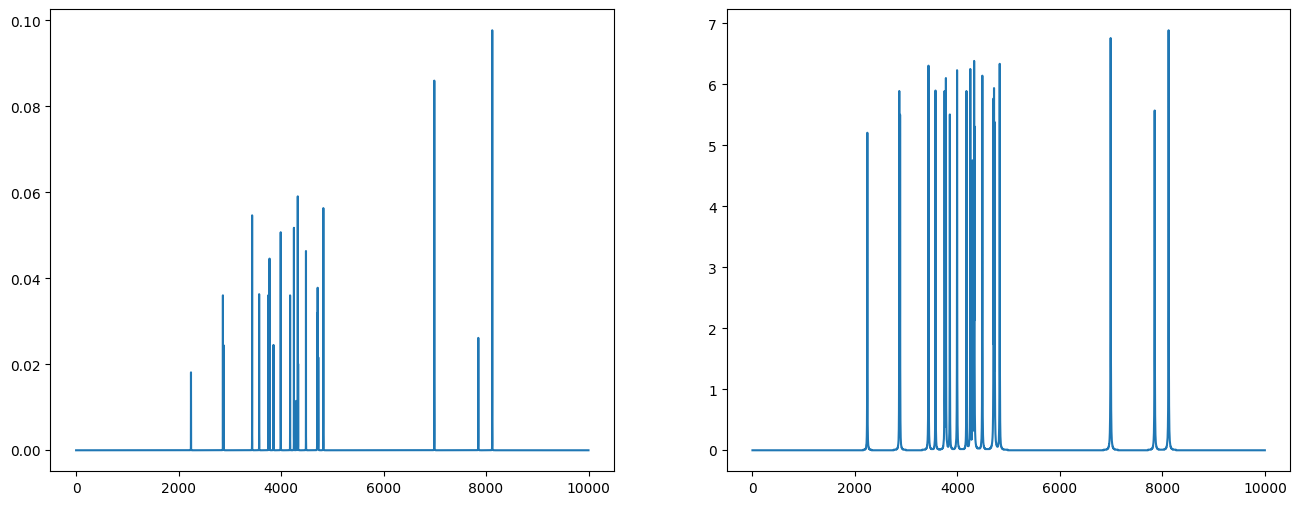

tensor(2886)


In [5]:
# visualization of raw and transformed data
idx = np.random.randint(len(train_data))
sample = train_data[idx]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(inverse_transform_data(sample))
axes[1].plot(sample)
plt.show()
print((sample != 0).sum())

In [7]:
# model
class ResBlock1d(nn.Module):
    """Residual block at fixed resolution (no stride). Used between strided layers."""
    def __init__(self, channels, kernel_size=17, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=kernel_size//2, groups=channels),  # depthwise
            nn.Conv1d(channels, channels, kernel_size=1),                                                      # pointwise
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=kernel_size//2, groups=channels),
            nn.Conv1d(channels, channels, kernel_size=1),
        )
        self.norm = nn.GroupNorm(num_groups=min(8, channels), num_channels=channels)

    def forward(self, x):
        return F.gelu(self.norm(x + self.block(x)))


class DownBlock(nn.Module):
    """Strided conv to halve/quarter resolution + one residual refinement."""
    def __init__(self, in_ch, out_ch, stride=4, dropout=0.1):
        super().__init__()
        self.down = nn.Conv1d(in_ch, out_ch, kernel_size=17, stride=stride, padding=8)
        self.norm = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)
        self.res  = ResBlock1d(out_ch, dropout=dropout)

    def forward(self, x):
        return self.res(F.gelu(self.norm(self.down(x))))


class UpBlock(nn.Module):
    """Strided convtranspose to double/quadruple resolution + one residual refinement."""
    def __init__(self, in_ch, out_ch, stride=4, dropout=0.1):
        super().__init__()
        self.up   = nn.ConvTranspose1d(in_ch, out_ch, kernel_size=17, stride=stride,
                                        padding=8, output_padding=stride-1)
        self.norm = nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch)
        self.res  = ResBlock1d(out_ch, dropout=dropout)

    def forward(self, x):
        return self.res(F.gelu(self.norm(self.up(x))))


class ConvVAERes(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout=0.1):
        super().__init__()

        # --- Encoder ---
        self.enc_in = nn.Conv1d(1, 8, kernel_size=1)   # channel lift, no spatial change
        self.down1  = DownBlock( 8, 16, stride=4, dropout=dropout)
        self.down2  = DownBlock(16, 32, stride=4, dropout=dropout)
        self.down3  = DownBlock(32, 32, stride=4, dropout=dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_dim)
            enc_out = self._encode_conv(dummy)
            self.enc_shape = enc_out.shape[1:]   # (32, ~157)
            flat_dim = enc_out.numel()
            print(f"flat_dim: {flat_dim}")

        self.fc_mu     = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, flat_dim)

        # --- Decoder (mirrors encoder) ---
        self.up1     = UpBlock(32, 32, stride=4, dropout=dropout)
        self.up2     = UpBlock(32, 16, stride=4, dropout=dropout)
        self.up3     = UpBlock(16,  8, stride=4, dropout=dropout)
        self.dec_out = nn.Conv1d(8, 1, kernel_size=7, padding=3)  # channel collapse + sharpening

        self.input_dim = input_dim

    def _encode_conv(self, x):
        x = F.gelu(self.enc_in(x))
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        return x

    def encode(self, x):
        h = self._encode_conv(x.unsqueeze(1)).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(mu) * (0.5 * logvar).exp()
        return mu

    def decode(self, z):
        h = F.gelu(self.fc_decode(z))
        h = h.view(z.size(0), *self.enc_shape)   # (B, 32, ~157)
        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        h = h[..., :self.input_dim]              # trim to exact length
        return self.dec_out(h).squeeze(1)        # (B, 10000)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        return F.softplus(self.decode(z)), mu, logvar


def vae_loss(preds, targets, mu, logvar, beta=0.1):
    rec = F.mse_loss(preds, targets)
    kl  = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return rec + beta * kl, rec, kl

In [8]:
# load model
device = 'cuda'
input_dim = data[0].shape[0]
latent_dim = 256
batch_size = 512

model = ConvVAERes(input_dim, latent_dim).to(device)
train_loader = DataLoader(train_data, batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size, shuffle=False)

model.load_state_dict(torch.load("/home/andrze06/projects/Spectras-latent-space/trained_models/SimpleConvRes-l256.pt", map_location=device))

flat_dim: 5024


<All keys matched successfully>

/tmp/ipykernel_1184419/204655779.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(val_data[idx], dtype=torch.float32, device=device).unsqueeze(0)


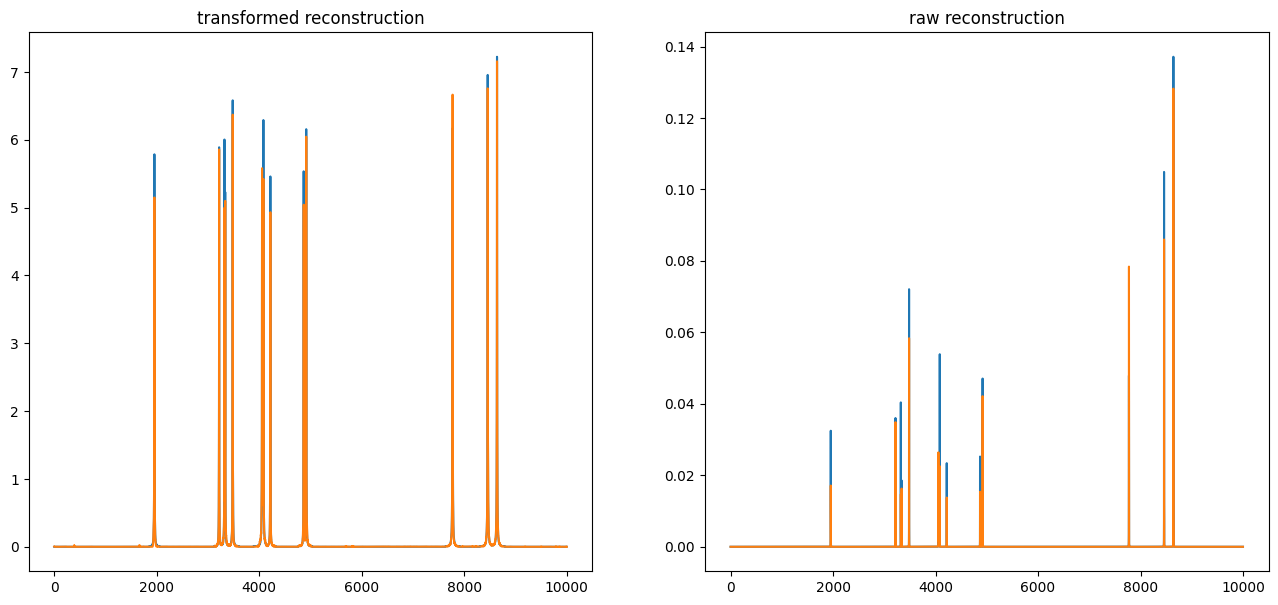

In [17]:
# example reconstruction
idx = np.random.randint(len(val_idx))
x = torch.tensor(val_data[idx], dtype=torch.float32, device=device).unsqueeze(0)

model.eval()
x_pred, mu, logvar = model(x)

x_np = x.cpu().detach().numpy()
x_pred_np = x_pred.cpu().detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(x_np[0])
axes[0].plot(x_pred_np[0])
axes[0].set_title('transformed reconstruction')
axes[1].plot(inverse_transform_data(x_np[0]))
axes[1].plot(inverse_transform_data(x_pred_np[0]))
axes[1].set_title('raw reconstruction')
plt.show()

[]

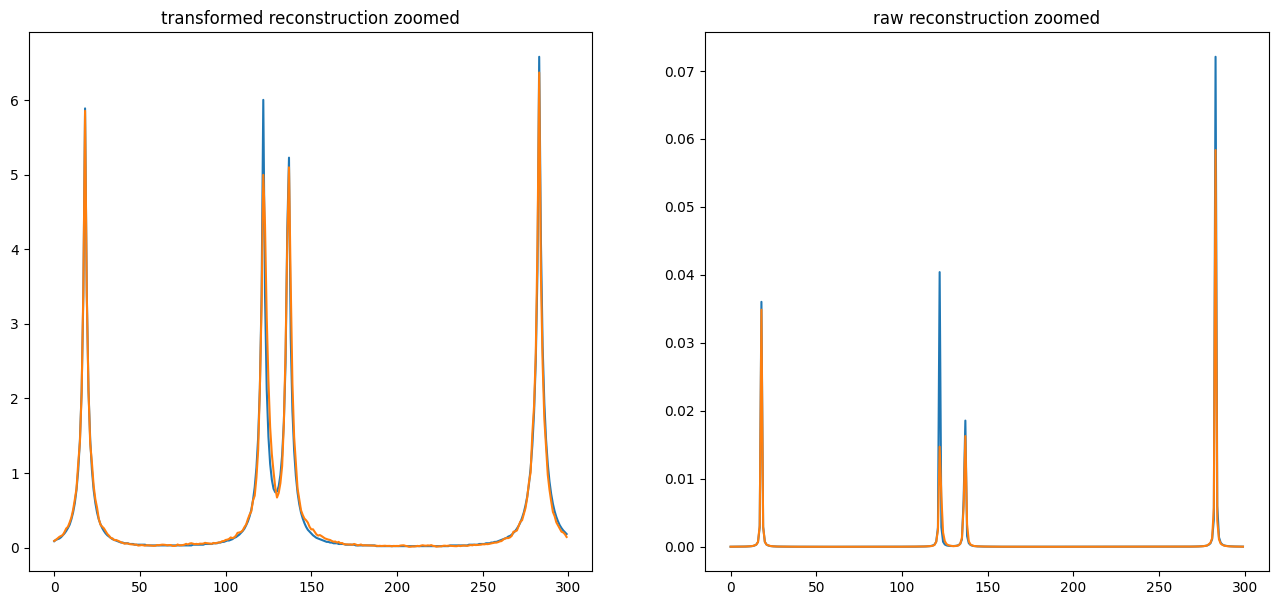

In [24]:
start_idx, end_idx = 3200, 3500
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].plot(x_np[0][start_idx:end_idx])
axes[0].plot(x_pred_np[0][start_idx:end_idx])
axes[0].set_title('transformed reconstruction zoomed')
axes[1].plot(inverse_transform_data(x_np[0][start_idx:end_idx]))
axes[1].plot(inverse_transform_data(x_pred_np[0][start_idx:end_idx]))
axes[1].set_title('raw reconstruction zoomed')
plt.plot()

In [25]:
# peak reconstruction stats
threshold = 0.5
peak_tolerance = 3
tp = fp = fn = 0

model.eval()
with torch.no_grad():
    for x in tqdm(val_loader):
        x = x.to(device)
        x_pred, _, _ = model(x)
        x_pred = x_pred.cpu().numpy()
        x = x.cpu().numpy()

        for true_spec, pred_spec in zip(x, x_pred):
            true_peaks, _ = find_peaks(true_spec, height=threshold)
            pred_peaks, _ = find_peaks(pred_spec, height=threshold)
            matched_true = set()

            for p in pred_peaks:
                found_match = False

                for i, t in enumerate(true_peaks):
                    if i in matched_true:
                        continue
                    if abs(p - t) <= peak_tolerance:
                        tp += 1
                        matched_true.add(i)
                        found_match = True
                        break
                if not found_match:
                    fp += 1
            fn += len(true_peaks) - len(matched_true)

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print(f"Precision={precision:.4f}")
print(f"Recall={recall:.4f}")
print(f"F1={f1:.4f}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 156/156 [00:21<00:00,  7.22it/s]

Precision=0.8957
Recall=0.9488
F1=0.9215


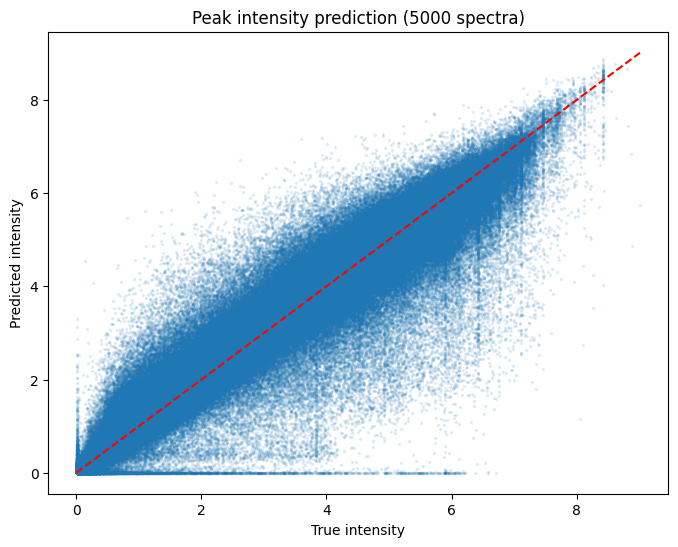

In [30]:
# show the regression plot
threshold = 0.0
n_samples = 5000

true_vals = []
pred_vals = []

model.eval()

collected = 0

with torch.no_grad():
    for x in val_loader:
        x = x.to(device)
        preds, _, _ = model(x)
        preds = preds.cpu().numpy()
        targets = x.cpu().numpy()

        for true_spec, pred_spec in zip(targets, preds):
            mask = true_spec > threshold
            true_vals.append(true_spec[mask])
            pred_vals.append(pred_spec[mask])
            collected += 1
            if collected >= n_samples:
                break
        if collected >= n_samples:
            break

true_peaks = np.concatenate(true_vals)
pred_peaks = np.concatenate(pred_vals)

plt.figure(figsize=(8, 6))
plt.scatter(true_peaks, pred_peaks, alpha=0.1, s=2)
m = max(true_peaks.max(), pred_peaks.max())
plt.plot([0, m], [0, m], 'r--')

plt.xlabel("True intensity")
plt.ylabel("Predicted intensity")
plt.title(f"Peak intensity prediction ({n_samples} spectra)")
plt.show()

In [33]:
# load selfies data
df = pd.read_csv('/data/home2/andrze06/projects/Smiles-latent-project/data/smiles_selfies_dataset.csv')

df['tokens'] = df['selfies'].apply(lambda x: list(sf.split_selfies(x)))
vocab = sorted(set([tok for seq in df['tokens'] for tok in seq]))
PAD, SOS, EOS, MASK = "<PAD>", "<SOS>", "<EOS>", "MASK"
vocab = [PAD, SOS, EOS, MASK] + vocab
vocab_size = len(vocab)

tok2id = {tok: idx for idx, tok in enumerate(vocab)}
id2tok = {idx: tok for tok, idx in tok2id.items()}

def molecule_tok2id(tokens, tok2id):
    return np.array([1] + [tok2id[t] for t in tokens] + [2])

df['token_ids'] = df['tokens'].apply(lambda toks: molecule_tok2id(toks, tok2id))

sequences = df['token_ids'].tolist()
max_len = max(len(seq) for seq in sequences)
padded_data = np.zeros((len(sequences), max_len), dtype=sequences[0].dtype)

for i, seq in enumerate(sequences):
    padded_data[i, :len(seq)] = seq

data_sf= padded_data#[:100_000]
train_data_sf, temp_data = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)
val_data_sf, test_data_sf = train_test_split(temp_data, test_size=0.5, random_state=42, shuffle=True)

: 

: 

: 